# 02 · Work-disjoint splits, and validating the Bangla POS tagger

Two pieces of methodology that decide whether the later numbers can be
believed at all.

**Splitting.** If passages are split at random, passages from the same novel
land on both sides. A classifier can then win by recognising a character name
— topic identification wearing style's clothes. Splitting over *works* removes
that route. The cost is that the realised split fractions drift from the
targets, because books differ in size; that drift is reported below rather
than hidden.

**POS tagger.** The proposal calls for POS n-grams "from a Bangla tagger".
There is no usable off-the-shelf one here (`stanza` ships no Bengali POS
model; `bnlp-toolkit` needs `gensim`, which has no Python 3.14 wheel), so the
tagger is written from scratch and **scored against the Universal
Dependencies Bengali treebank** so the reader can discount the POS features
appropriately.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Bengali glyphs need a font that has them; fall back silently if absent.
for _f in ("Nirmala UI", "Vrinda", "Shonar Bangla", "Noto Sans Bengali"):
    try:
        matplotlib.font_manager.findfont(_f, fallback_to_default=False)
        plt.rcParams["font.family"] = _f
        break
    except Exception:
        continue
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.25})
pd.set_option("display.width", 160, "display.max_columns", 60)

from banglastylo import config
print("project root:", ROOT)

project root: E:\4-1\NLP Project


## 2.1 Build the split

In [2]:
from banglastylo import corpus, splits

passages = corpus.load_passages()
split = splits.split_by_work(passages)
splits.save(split)

print("split sizes:", split.counts())
total = sum(split.counts().values())
for k, v in split.counts().items():
    print(f"  {k:5s} {v:5d}  ({v/total:.1%})")

wrote E:\4-1\NLP Project\data\splits\split.json
split sizes: {'train': 1821, 'val': 422, 'test': 712}
  train  1821  (61.6%)
  val     422  (14.3%)
  test    712  (24.1%)


### The leakage check

This is not decoration. It asserts the invariant the whole evaluation rests
on: no work, and no passage, appears in two splits.

In [3]:
report = splits.leakage_report(split)
print("clean:", report["clean"])
for k, v in report["overlaps"].items():
    print(f"  {k:24s} {v}")
assert report["clean"], "LEAKAGE: a work or passage spans two splits"
print("\nno work and no passage crosses a split boundary.")

clean: True
  train|val:works          []
  train|val:passages       0
  train|test:works         []
  train|test:passages      0
  val|test:works           []
  val|test:passages        0

no work and no passage crosses a split boundary.


## 2.2 Per-author split composition

In [4]:
desc = pd.DataFrame(splits.describe(split)).T
desc["author"] = [config.AUTHORS[a]["en"] for a in desc.index]
desc = desc[["author", "train", "val", "test",
             "works_train", "works_val", "works_test"]]
desc.to_csv(config.TABLES / "split_composition.csv")
desc

,author,train,val,test,works_train,works_val,works_test
abanindranath,Abanindranath Tagore,369,97,125,3,1,1
bankim,Bankim Chandra Chattopadhyay,365,90,136,3,1,2
sarat,Sarat Chandra Chattopadhyay,377,59,155,2,1,2
tagore,Rabindranath Tagore,355,89,147,6,5,3
vidyasagar,Ishwar Chandra Vidyasagar,355,87,149,5,4,3


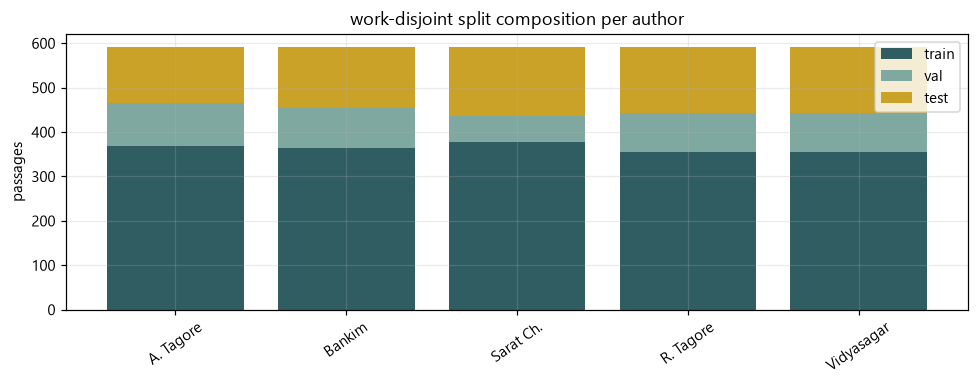

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.6))
names = [config.AUTHORS[a]["short"] for a in desc.index]
bottom = np.zeros(len(desc))
for part, colour in (("train", "#2F5D62"), ("val", "#7FA8A0"), ("test", "#C9A227")):
    vals = desc[part].to_numpy(dtype=float)
    ax.bar(names, vals, bottom=bottom, label=part, color=colour)
    bottom += vals
ax.set_ylabel("passages")
ax.set_title("work-disjoint split composition per author")
ax.tick_params(axis="x", rotation=35)
ax.legend()
fig.tight_layout()
fig.savefig(config.FIGURES / "split_composition.png", dpi=200)
fig.savefig(config.REPORT_FIGURES / "split_composition.png", dpi=200)
plt.show()

## 2.3 How much does work-disjoint splitting actually matter?

Worth measuring rather than asserting. The same model is trained twice — once
on the honest work-disjoint split, once on a naive random split of the same
passages. The gap is the size of the topic-leak the discipline buys away.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from banglastylo.models import build_svm_pipeline

Xtr, ytr = splits.xy(split.train)
Xte, yte = splits.xy(split.test)

pipe = build_svm_pipeline(families=("funcword", "structural", "charngram"))
pipe.fit(Xtr, ytr)
acc_honest = accuracy_score(yte, pipe.predict(Xte))

texts = [p.text for p in passages]
labels = [p.author for p in passages]
rXtr, rXte, rytr, ryte = train_test_split(
    texts, labels, test_size=0.25, random_state=config.SEED, stratify=labels)
pipe_naive = build_svm_pipeline(families=("funcword", "structural", "charngram"))
pipe_naive.fit(rXtr, rytr)
acc_naive = accuracy_score(ryte, pipe_naive.predict(rXte))

print(f"random passage-level split (leaky) : {acc_naive:.4f}")
print(f"work-disjoint split (honest)       : {acc_honest:.4f}")
print(f"inflation from topic leakage       : {acc_naive - acc_honest:+.4f}")

json.dump({"random_split_accuracy": acc_naive,
           "work_disjoint_accuracy": acc_honest,
           "leakage_inflation": acc_naive - acc_honest},
          open(config.TABLES / "leakage_experiment.json", "w"), indent=2)

random passage-level split (leaky) : 0.9932
work-disjoint split (honest)       : 0.7865
inflation from topic leakage       : +0.2067


## 2.4 Validating the POS tagger

Scored against `UD_Bengali-BRU`, the only Universal Dependencies treebank for
Bengali — 56 sentences, test-only, which is why it can be used for evaluation
but not for training.

Three UD distinctions are deliberately not attempted and are folded before
scoring: `AUX`→`VERB` (Bangla auxiliaries are ordinary verbs in ordinary verb
forms), `PROPN`→`NOUN` (needs a name gazetteer that does not exist for
19th-century Bangla), `SCONJ`→`CCONJ` (the stylometric feature of interest is
conjunction density, not subtype). Each fold loses information rather than
inventing it.

In [7]:
from banglastylo import postag
import urllib.request

ud_path = config.RAW / "bn_bru-ud-test.conllu"
if not ud_path.exists():
    url = ("https://raw.githubusercontent.com/UniversalDependencies/"
           "UD_Bengali-BRU/master/bn_bru-ud-test.conllu")
    ud_path.write_text(urllib.request.urlopen(url, timeout=60)
                       .read().decode("utf-8"), encoding="utf-8")

ev = postag.evaluate_on_ud(ud_path)
print(f"UD_Bengali-BRU: {ev['n_sentences']} sentences, {ev['n_tokens']} tokens")
print(f"token accuracy: {ev['accuracy']:.4f}")
json.dump(ev, open(config.TABLES / "postag_eval.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=2)

pd.DataFrame(ev["per_tag"]).T.assign(
    support=lambda d: d["support"].astype(int)).sort_values("support",
                                                            ascending=False)

UD_Bengali-BRU: 56 sentences, 320 tokens
token accuracy: 0.8719


,support,recall
PUNCT,73,1.000000
VERB,71,0.971831
NOUN,66,0.818182
PRON,49,0.979592
DET,14,0.285714
ADJ,13,0.769231
ADV,13,0.461538
PART,9,0.777778
INTJ,6,0.500000
ADP,2,0.500000


In [8]:
print("most frequent tagger confusions (gold -> predicted):")
for (gold, pred), n in ev["top_confusions"]:
    print(f"  {gold:6s} -> {pred:6s}  {n:3d}")

most frequent tagger confusions (gold -> predicted):
  NOUN   -> VERB     10
  DET    -> PRON      7
  ADV    -> ADP       4
  INTJ   -> PART      3
  ADV    -> CCONJ     3
  ADJ    -> NUM       2
  DET    -> PART      2
  PART   -> PRON      2
  VERB   -> NOUN      2
  DET    -> CCONJ     1
  PRON   -> VERB      1
  ADJ    -> ADV       1


### The tagger on the proposal's own worked example

The proposal's example sentence claims a `NOUN–VERB–ADP–NOUN` pattern and
picks out the postpositions পাশে and দিকে and the pronoun সে. Running the
tagger on it is the cheapest possible sanity check that it recovers what the
proposal says it should.

In [9]:
from banglastylo.normalize import normalize_text, word_tokenize

sentence = normalize_text(
    "বৃষ্টি থামলে সে জানালার পাশে দাঁড়িয়ে দূরের আকাশের দিকে তাকিয়ে রইল।")
toks = word_tokenize(sentence, keep_punct=True)
tags = postag.tag(toks)
pd.DataFrame({"token": toks, "tag": tags}).T

,0,1,2,3,4,5,6,7,8,9,10,11
token,বৃষ্টি,থামলে,সে,জানালার,পাশে,দাঁড়িয়ে,দূরের,আকাশের,দিকে,তাকিয়ে,রইল,।
tag,NOUN,NOUN,PRON,NOUN,ADP,VERB,NOUN,NOUN,ADP,VERB,NOUN,PUNCT
